In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [27]:
df=pd.read_csv('Video_data_set.csv')

In [28]:
df.head()

,s_video_id,s_width,s_height,s_storage_size,s_duration,s_scan_type,c_content_category,c_si,c_ti,c_scene_change_ffmpeg_ratio30,...,e_b_frame_int,e_ref_frame_count,e_scan_type,e_bit_depth,e_pixel_fmt,t_average_bitrate,t_average_vmaf,t_average_vmaf_mobile,t_average_vmaf_4k,t_average_psnr
0,8,1920,1080,521709628,65,progressive,maze,63.04,14.48,11.076923,...,3,1.0,progressive,8.0,yuv420p,31214,97.204616,NaN,NaN,NaN
1,8,1920,1080,521709628,65,progressive,maze,63.04,14.48,11.076923,...,3,1.0,progressive,8.0,yuv420p,2750,67.255472,NaN,NaN,NaN
2,8,1920,1080,521709628,65,progressive,maze,63.04,14.48,11.076923,...,3,1.0,progressive,8.0,yuv420p,10777,90.423618,NaN,NaN,NaN
3,8,1920,1080,521709628,65,progressive,maze,63.04,14.48,11.076923,...,3,1.0,progressive,8.0,yuv420p,5990,83.276829,NaN,NaN,NaN
4,8,1920,1080,521709628,65,progressive,maze,63.04,14.48,11.076923,...,3,1.0,progressive,8.0,yuv420p,3766,75.562682,NaN,NaN,NaN


# 📊 Dataset Column Descriptions

This dataset contains information about video sources, their content characteristics, encoding settings, and resulting quality metrics.

---

## 🔹 1. Source Video Information (`s_`)

These columns describe the original input video properties.

- **`s_video_id`**: Unique identifier for each video  
- **`s_width` / `s_height`**: Resolution of the source video (in pixels)  
- **`s_storage_size`**: File size of the source video (bytes)  
- **`s_duration`**: Duration of the video (in seconds)  
- **`s_scan_type`**: Scan format (e.g., progressive or interlaced)

---

## 🔹 2. Content Features (`c_`)

These features capture the visual characteristics and complexity of the video.

### 📌 General Content Metrics
- **`c_content_category`**: Type of content (e.g., sports, animation, movie)  
- **`c_si` (Spatial Information)**: Measures spatial detail/texture complexity  
- **`c_ti` (Temporal Information)**: Measures motion intensity across frames  

### 📌 Scene Change Metrics
- **`c_scene_change_ffmpeg_ratio30/60/90`**: Scene change ratios using FFmpeg at different thresholds  
- **`c_scene_change_py_thresh30/50`**: Scene change detection using Python-based thresholds  

### 📌 Color Histogram Features

#### Mean Brightness Levels
- `c_colorhistogram_mean_dark`  
- `c_colorhistogram_mean_medium_dark`  
- `c_colorhistogram_mean_medium_bright`  
- `c_colorhistogram_mean_bright`  

#### Brightness Variation (Standard Deviation)
- `c_colorhistogram_std_dev_dark`  
- `c_colorhistogram_std_dev_medium_dark`  
- `c_colorhistogram_std_dev_medium_bright`  
- `c_colorhistogram_std_dev_bright`  

#### Temporal Brightness Variation
- `c_colorhistogram_temporal_mean_std_dev_dark`  
- `c_colorhistogram_temporal_mean_std_dev_medium_dark`  
- `c_colorhistogram_temporal_mean_std_dev_medium_bright`  
- `c_colorhistogram_temporal_mean_std_dev_bright`  

---

## 🔹 3. Encoding Parameters (`e_`)

These columns describe how the video was encoded or compressed.

- **`e_crf`**: Constant Rate Factor (lower = higher quality)  
- **`e_width` / `e_height`**: Output resolution  
- **`e_aspect_ratio`**: Display aspect ratio  
- **`e_pixel_aspect_ratio`**: Pixel aspect ratio  
- **`e_codec`**: Video codec used (e.g., H.264, H.265)  
- **`e_codec_profile`**: Codec profile (e.g., baseline, main, high)  
- **`e_codec_level`**: Codec level constraints  
- **`e_framerate`**: Frames per second  
- **`e_gop_size`**: Group of Pictures (GOP) size  
- **`e_b_frame_int`**: Interval or number of B-frames  
- **`e_ref_frame_count`**: Number of reference frames  
- **`e_scan_type`**: Output scan type  
- **`e_bit_depth`**: Bit depth (e.g., 8-bit, 10-bit)  
- **`e_pixel_fmt`**: Pixel format (e.g., yuv420p)

---

## 🔹 4. Target / Quality Metrics (`t_`)

These represent the output performance and perceived quality after encoding.

- **`t_average_bitrate`**: Average bitrate (compression efficiency)  
- **`t_average_vmaf`**: VMAF score (perceptual video quality)  
- **`t_average_vmaf_mobile`**: VMAF score optimized for mobile viewing  
- **`t_average_vmaf_4k`**: VMAF score optimized for 4K displays  
- **`t_average_psnr`**: PSNR (Peak Signal-to-Noise Ratio)

---

## 🧠 Summary

- **`s_`** → Source video properties  
- **`c_`** → Content complexity/features  
- **`e_`** → Encoding settings  
- **`t_`** → Output quality metrics  

---

In [29]:
df.columns

Index(['s_video_id', 's_width', 's_height', 's_storage_size', 's_duration',
       's_scan_type', 'c_content_category', 'c_si', 'c_ti',
       'c_scene_change_ffmpeg_ratio30', 'c_scene_change_ffmpeg_ratio60',
       'c_scene_change_ffmpeg_ratio90', 'c_scene_change_py_thresh30',
       'c_scene_change_py_thresh50', 'c_colorhistogram_mean_dark',
       'c_colorhistogram_mean_medium_dark',
       'c_colorhistogram_mean_medium_bright', 'c_colorhistogram_mean_bright',
       'c_colorhistogram_std_dev_dark', 'c_colorhistogram_std_dev_medium_dark',
       'c_colorhistogram_std_dev_medium_bright',
       'c_colorhistogram_std_dev_bright',
       'c_colorhistogram_temporal_mean_std_dev_dark',
       'c_colorhistogram_temporal_mean_std_dev_medium_dark',
       'c_colorhistogram_temporal_mean_std_dev_medium_bright',
       'c_colorhistogram_temporal_mean_std_dev_bright', 'e_crf', 'e_width',
       'e_height', 'e_aspect_ratio', 'e_pixel_aspect_ratio', 'e_codec',
       'e_codec_profile', 'e_codec_

In [30]:
df.shape

(10570, 46)

In [31]:
df.s_video_id.unique()

array([  8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97, 210, 211, 212, 213, 214, 215, 216, 217,
       218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230,
       231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243,
       244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256,
       257, 265, 266, 267, 268, 269, 271, 272, 273, 274, 284, 285, 286,
       287, 288, 289, 290, 291, 299, 300, 301, 302, 303, 304, 305, 306,
       308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320,
       321, 322, 323, 324, 325, 326, 327, 328, 329])

In [32]:
df_drop=df.drop(['e_aspect_ratio',
                 'e_pixel_aspect_ratio',
                 'e_codec',
                 'e_codec_profile',
                 'e_codec_level',
                 'e_b_frame_int',
                 'e_ref_frame_count',
                 'e_scan_type',
                 'e_bit_depth',
                 'e_pixel_fmt',
                 't_average_vmaf',
                 't_average_vmaf_4k',
                 't_average_psnr',
                 "t_average_vmaf_mobile",
                 "s_scan_type"], axis=1)

In [33]:
df_drop.shape

(10570, 31)

In [34]:
data_set_c=df_drop.copy()

data_set_c.drop_duplicates(inplace=True)



In [35]:
data_set_c.shape

(9834, 31)

In [36]:
data_set_c.isnull().sum()

s_video_id                                                0
s_width                                                   0
s_height                                                  0
s_storage_size                                            0
s_duration                                                0
c_content_category                                      230
c_si                                                    752
c_ti                                                    752
c_scene_change_ffmpeg_ratio30                             0
c_scene_change_ffmpeg_ratio60                             0
c_scene_change_ffmpeg_ratio90                             0
c_scene_change_py_thresh30                                0
c_scene_change_py_thresh50                                0
c_colorhistogram_mean_dark                              145
c_colorhistogram_mean_medium_dark                       145
c_colorhistogram_mean_medium_bright                     145
c_colorhistogram_mean_bright            

In [37]:
data_set_c.dropna(inplace=True)

In [38]:
data_set_c.isnull().sum()

s_video_id                                              0
s_width                                                 0
s_height                                                0
s_storage_size                                          0
s_duration                                              0
c_content_category                                      0
c_si                                                    0
c_ti                                                    0
c_scene_change_ffmpeg_ratio30                           0
c_scene_change_ffmpeg_ratio60                           0
c_scene_change_ffmpeg_ratio90                           0
c_scene_change_py_thresh30                              0
c_scene_change_py_thresh50                              0
c_colorhistogram_mean_dark                              0
c_colorhistogram_mean_medium_dark                       0
c_colorhistogram_mean_medium_bright                     0
c_colorhistogram_mean_bright                            0
c_colorhistogr

In [39]:
data_set_c.shape

(8780, 31)

In [40]:
data_set_c.sort_values(by=['s_video_id'],inplace=True)

In [41]:
data_set_c.reset_index(inplace=True,drop=True)

In [42]:
data_set_cleaned=data_set_c.copy()

In [43]:
data_set_cleaned['Res_width_height']=data_set_cleaned['e_width']*data_set_cleaned['e_height']

In [44]:
data_set_cleaned['Scene_Change_average']=data_set_cleaned['c_scene_change_ffmpeg_ratio30']*60/data_set_cleaned['s_duration']

In [45]:
data_set_cleaned.head()

,s_video_id,s_width,s_height,s_storage_size,s_duration,c_content_category,c_si,c_ti,c_scene_change_ffmpeg_ratio30,c_scene_change_ffmpeg_ratio60,...,c_colorhistogram_temporal_mean_std_dev_medium_bright,c_colorhistogram_temporal_mean_std_dev_bright,e_crf,e_width,e_height,e_framerate,e_gop_size,t_average_bitrate,Res_width_height,Scene_Change_average
0,8,1920,1080,521709628,65,maze,63.04,14.48,11.076923,0.923077,...,0.100943,0.110025,18,1920,1080,50.0,100.0,31214,2073600,10.224852
1,8,1920,1080,521709628,65,maze,63.04,14.48,11.076923,0.923077,...,0.100943,0.110025,18,640,360,50.0,100.0,2750,230400,10.224852
2,8,1920,1080,521709628,65,maze,63.04,14.48,11.076923,0.923077,...,0.100943,0.110025,18,1280,720,50.0,100.0,10777,921600,10.224852
3,8,1920,1080,521709628,65,maze,63.04,14.48,11.076923,0.923077,...,0.100943,0.110025,18,960,540,50.0,100.0,5990,518400,10.224852
4,8,1920,1080,521709628,65,maze,63.04,14.48,11.076923,0.923077,...,0.100943,0.110025,18,768,432,50.0,100.0,3766,331776,10.224852


In [46]:
data_set_cleaned['Scene_Change_average']

0       10.224852
1       10.224852
2       10.224852
3       10.224852
4       10.224852
          ...    
8775     0.930748
8776     0.930748
8777     0.930748
8778     0.930748
8779     0.930748
Name: Scene_Change_average, Length: 8780, dtype: float64

<Axes: xlabel='t_average_bitrate'>

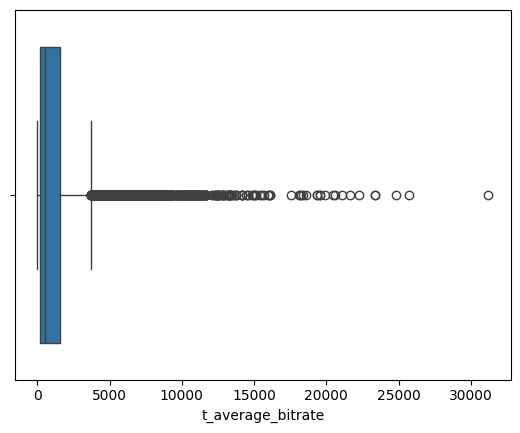

In [47]:
sns.boxplot(x=data_set_cleaned['t_average_bitrate'])

In [48]:
data_set_cleaned['t_average_bitrate'].describe()

count     8780.000000
mean      1416.931891
std       2352.531715
min          8.000000
25%        154.000000
50%        535.000000
75%       1583.250000
max      31214.000000
Name: t_average_bitrate, dtype: float64

In [49]:
Q1 = data_set_cleaned['t_average_bitrate'].quantile(0.25)
Q3 = data_set_cleaned['t_average_bitrate'].quantile(0.75)

IQR = Q3 - Q1
max_threshold = Q3 + 3 * IQR

data_set_cleaned.loc[
    data_set_cleaned['t_average_bitrate'] >= max_threshold,
    't_average_bitrate'
] = np.nan

In [50]:
data_set_cleaned.isnull().sum()

s_video_id                                                0
s_width                                                   0
s_height                                                  0
s_storage_size                                            0
s_duration                                                0
c_content_category                                        0
c_si                                                      0
c_ti                                                      0
c_scene_change_ffmpeg_ratio30                             0
c_scene_change_ffmpeg_ratio60                             0
c_scene_change_ffmpeg_ratio90                             0
c_scene_change_py_thresh30                                0
c_scene_change_py_thresh50                                0
c_colorhistogram_mean_dark                                0
c_colorhistogram_mean_medium_dark                         0
c_colorhistogram_mean_medium_bright                       0
c_colorhistogram_mean_bright            

<Axes: xlabel='t_average_bitrate'>

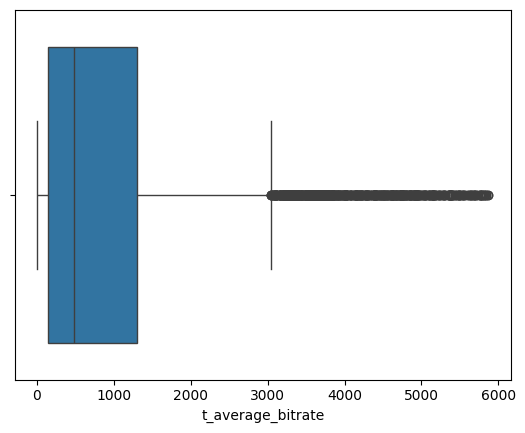

In [51]:
sns.boxplot(x=data_set_cleaned['t_average_bitrate'])

In [52]:
data_set_final=data_set_cleaned.copy()

data_set_final= data_set_final.drop("c_content_category",axis=1)

<Axes: >

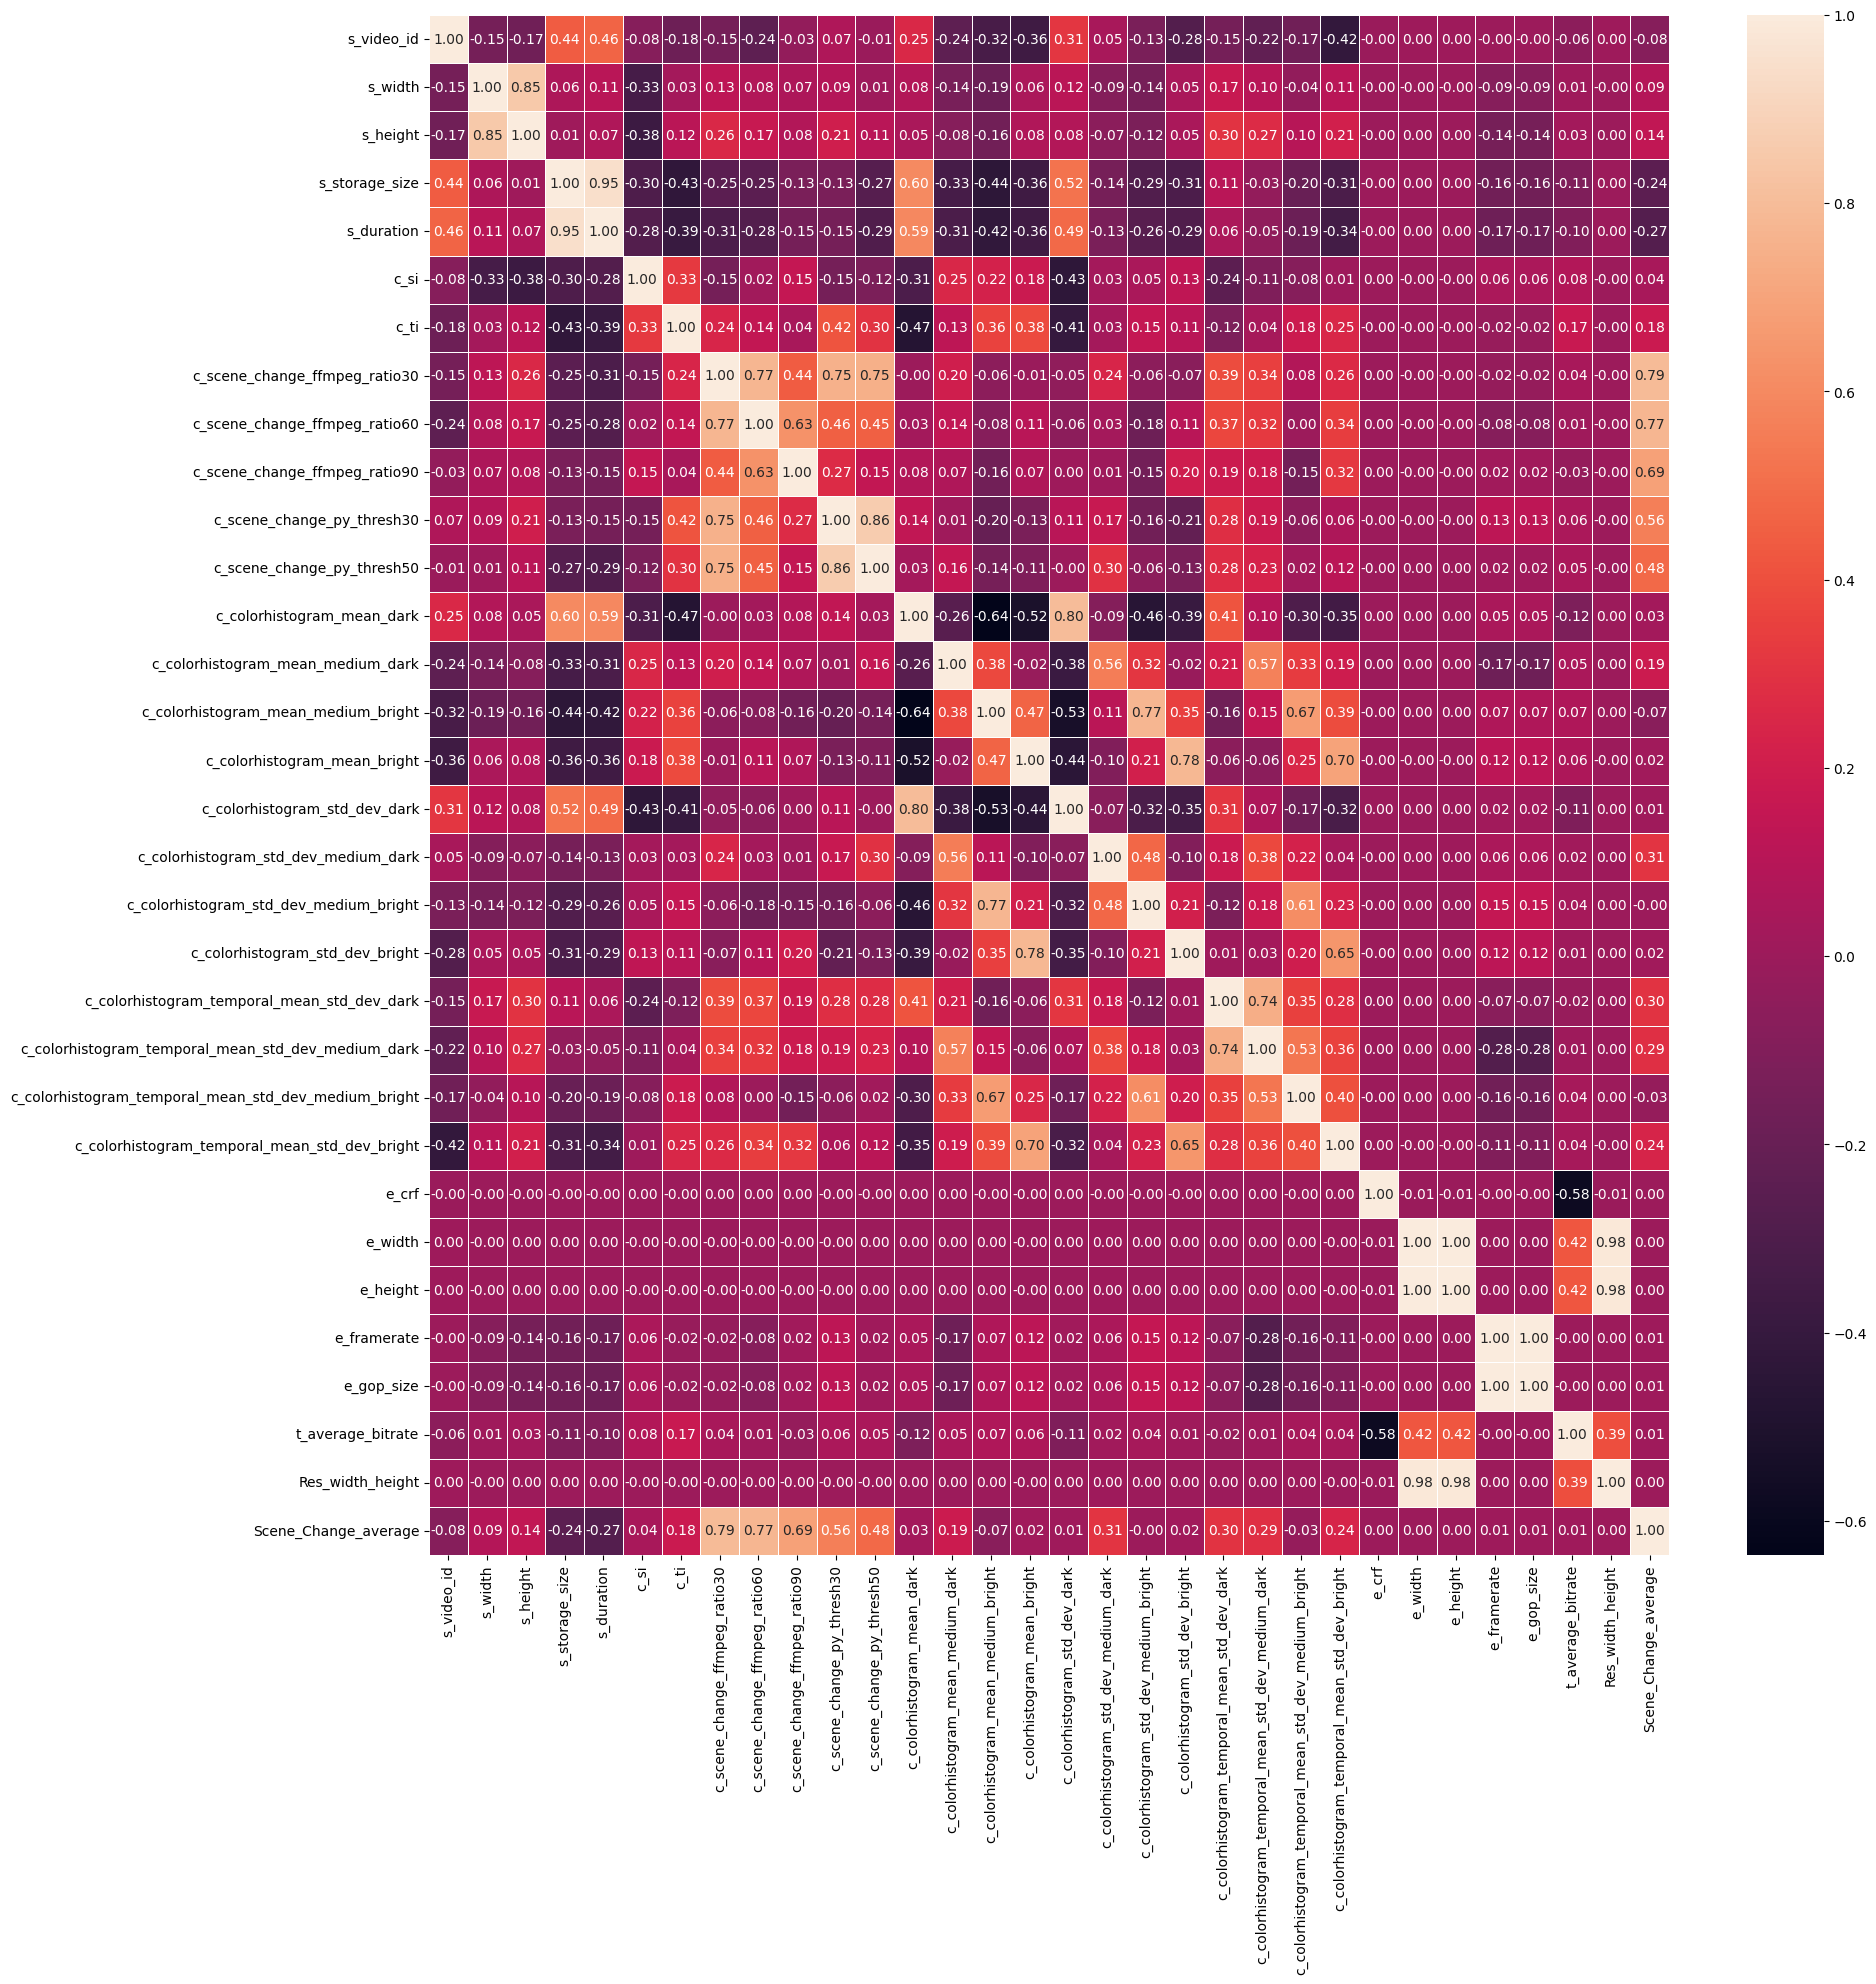

In [53]:
corrmatrix=data_set_final.corr(method='pearson')
fix,ax = plt.subplots(figsize=(20,20))
sns.heatmap(corrmatrix,annot=True,linewidths=0.5,fmt='.2f',ax=ax)

In [54]:
data_set_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 8780 entries, 0 to 8779
Data columns (total 32 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   s_video_id                                            8780 non-null   int64  
 1   s_width                                               8780 non-null   int64  
 2   s_height                                              8780 non-null   int64  
 3   s_storage_size                                        8780 non-null   int64  
 4   s_duration                                            8780 non-null   int64  
 5   c_si                                                  8780 non-null   float64
 6   c_ti                                                  8780 non-null   float64
 7   c_scene_change_ffmpeg_ratio30                         8780 non-null   float64
 8   c_scene_change_ffmpeg_ratio60                         8780 non-null  